In [4]:
# ============================================================
# REAL-WORLD DATA PROJECT
# BANKING CUSTOMER ANALYSIS
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
# Load banking dataset

df = pd.read_excel(r"C:\Users\user\Downloads\banking Data.xlsx")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])# Load banking dataset



Dataset loaded successfully!
Rows: 3000
Columns: 25


In [6]:
df.head()
df.info()
df.describe(include="all").T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Client ID                 3000 non-null   object        
 1   Name                      3000 non-null   object        
 2   Age                       3000 non-null   int64         
 3   Sex                       3000 non-null   object        
 4   Location ID               3000 non-null   int64         
 5   Joined Bank               3000 non-null   datetime64[ns]
 6   Banking Contact           3000 non-null   object        
 7   Nationality               3000 non-null   object        
 8   Occupation                3000 non-null   object        
 9   Investment Advisor        3000 non-null   object        
 10  Fee Structure             3000 non-null   object        
 11  Loyalty Classification    3000 non-null   object        
 12  Banking Relationship

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Client ID,3000,2940,PKR48103,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Name,3000,2913,Raymond Mills,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,3000.0,NaN,NaN,NaN,51.039667,17.0,34.0,51.0,69.0,85.0,19.85476
Sex,3000,2,Female,1512,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location ID,3000.0,NaN,NaN,NaN,21563.323,12.0,10803.5,21129.5,32054.5,43369.0,12462.273017
Joined Bank,3000,NaN,NaN,NaN,2006-01-27 22:29:45.600000128,1992-05-23 00:00:00,1998-12-30 18:00:00,2006-02-11 00:00:00,2013-03-06 00:00:00,2019-09-12 00:00:00,NaN
Banking Contact,3000,49,Ernest Rivera,77,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Nationality,3000,5,European,1309,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Occupation,3000,195,Structural Analysis Engineer,28,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Investment Advisor,3000,22,Eugene Cunningham,155,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
missing_values = df.isnull().sum()

missing_report = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": (
        missing_values / len(df) * 100
    )
})

missing_report[
    missing_report["Missing Values"] > 0
]

,Missing Values,Missing Percentage


In [8]:
duplicate_count = df.duplicated().sum()

print("Duplicate records:", duplicate_count)

Duplicate records: 0


In [9]:
print("Data Types:")
print(df.dtypes)

Data Types:
Client ID                           object
Name                                object
Age                                  int64
Sex                                 object
Location ID                          int64
Joined Bank                 datetime64[ns]
Banking Contact                     object
Nationality                         object
Occupation                          object
Investment Advisor                  object
Fee Structure                       object
Loyalty Classification              object
Banking Relationship                object
Estimated Income                   float64
Superannuation Savings             float64
Amount of Credit Cards               int64
Credit Card Balance                float64
Bank Loans                         float64
Bank Deposits                      float64
Checking Accounts                  float64
Saving Accounts                    float64
Foreign Currency Account           float64
Business Lending                   float64

In [10]:
# Convert Joined Bank into datetime

df["Joined Bank"] = pd.to_datetime(
    df["Joined Bank"],
    errors="coerce"
)

# Create useful time features

df["Join Year"] = df["Joined Bank"].dt.year

df["Join Month"] = df["Joined Bank"].dt.month

print("Date processing completed.")

Date processing completed.


In [11]:
print("Age range:")
print(df["Age"].min(), "-", df["Age"].max())

print("\nRisk Weighting range:")
print(
    df["Risk Weighting"].min(),
    "-",
    df["Risk Weighting"].max()
)

print("\nNumber of Credit Cards:")
print(
    df["Amount of Credit Cards"].min(),
    "-",
    df["Amount of Credit Cards"].max()
)

Age range:
17 - 85

Risk Weighting range:
1 - 5

Number of Credit Cards:
1 - 3


In [12]:
# Check potentially invalid financial values

financial_columns = [
    "Estimated Income",
    "Superannuation Savings",
    "Credit Card Balance",
    "Bank Loans",
    "Bank Deposits",
    "Checking Accounts",
    "Saving Accounts",
    "Foreign Currency Account",
    "Business Lending"
]

for column in financial_columns:
    
    negative_values = (
        df[column] < 0
    ).sum()
    
    print(
        column,
        "-> Negative values:",
        negative_values
    )

Estimated Income -> Negative values: 0
Superannuation Savings -> Negative values: 0
Credit Card Balance -> Negative values: 0
Bank Loans -> Negative values: 0
Bank Deposits -> Negative values: 0
Checking Accounts -> Negative values: 0
Saving Accounts -> Negative values: 0
Foreign Currency Account -> Negative values: 0
Business Lending -> Negative values: 0


In [13]:
print("=" * 60)
print("BANKING CUSTOMER OVERVIEW")
print("=" * 60)

print("Total Customers:", df["Client ID"].nunique())

print(
    "Average Age:",
    round(df["Age"].mean(), 2)
)

print(
    "Average Estimated Income:",
    round(df["Estimated Income"].mean(), 2)
)

print(
    "Average Bank Deposits:",
    round(df["Bank Deposits"].mean(), 2)
)

print(
    "Average Bank Loans:",
    round(df["Bank Loans"].mean(), 2)
)

print(
    "Average Properties Owned:",
    round(df["Properties Owned"].mean(), 2)
)

BANKING CUSTOMER OVERVIEW
Total Customers: 2940
Average Age: 51.04
Average Estimated Income: 171305.03
Average Bank Deposits: 671560.19
Average Bank Loans: 591386.16
Average Properties Owned: 1.52


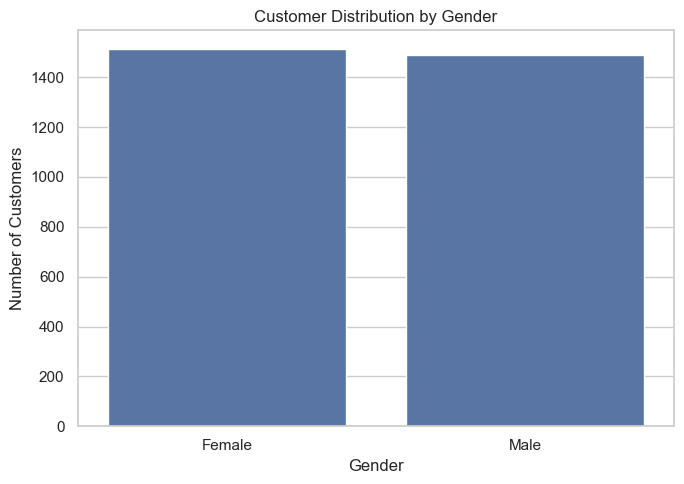

In [14]:
gender_count = df["Sex"].value_counts()

plt.figure(figsize=(7, 5))

sns.barplot(
    x=gender_count.index,
    y=gender_count.values
)

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

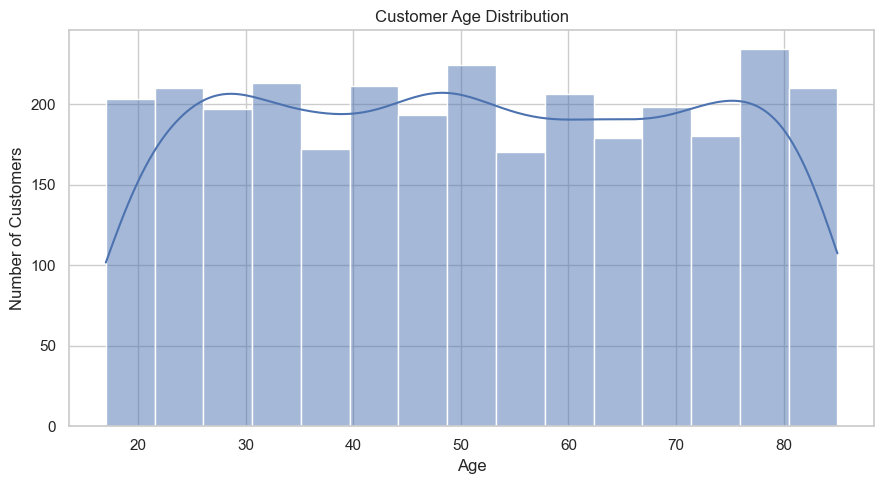

In [15]:
#Age Distribution
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="Age",
    bins=15,
    kde=True
)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

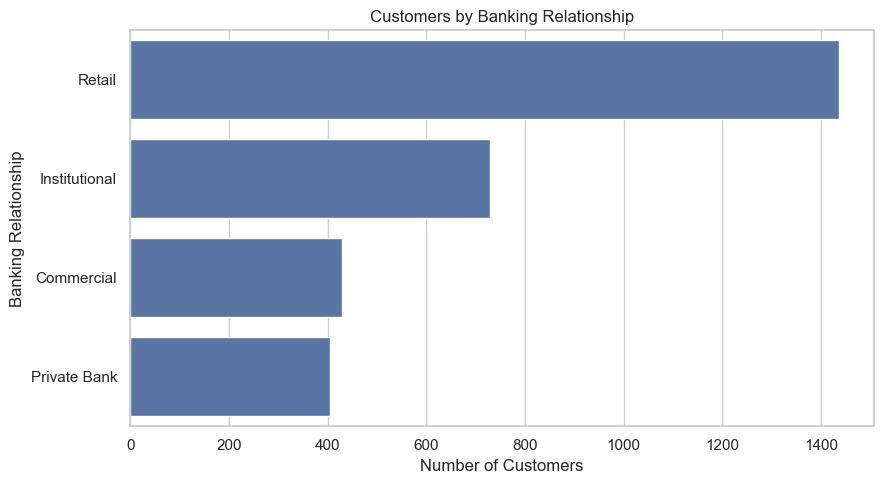

In [16]:
relationship_count = (
    df["Banking Relationship"]
    .value_counts()
)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=relationship_count.values,
    y=relationship_count.index
)

plt.title("Customers by Banking Relationship")
plt.xlabel("Number of Customers")
plt.ylabel("Banking Relationship")

plt.tight_layout()
plt.show()

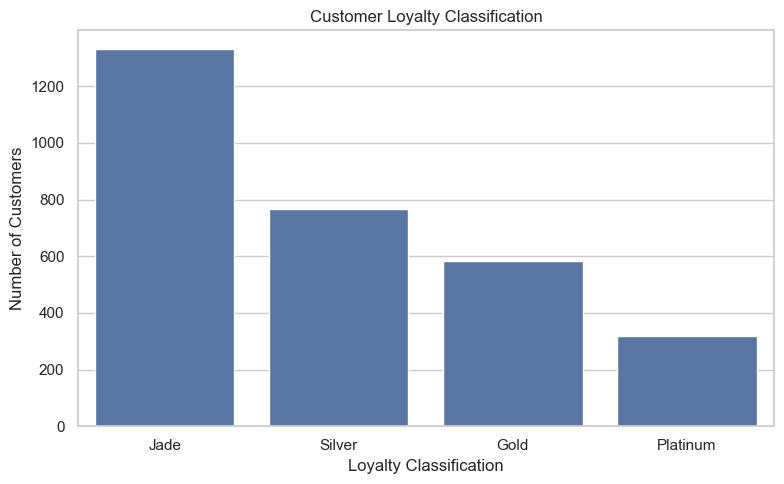

In [17]:
#Loyalty Classification

loyalty_count = (
    df["Loyalty Classification"]
    .value_counts()
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=loyalty_count.index,
    y=loyalty_count.values
)

plt.title("Customer Loyalty Classification")
plt.xlabel("Loyalty Classification")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

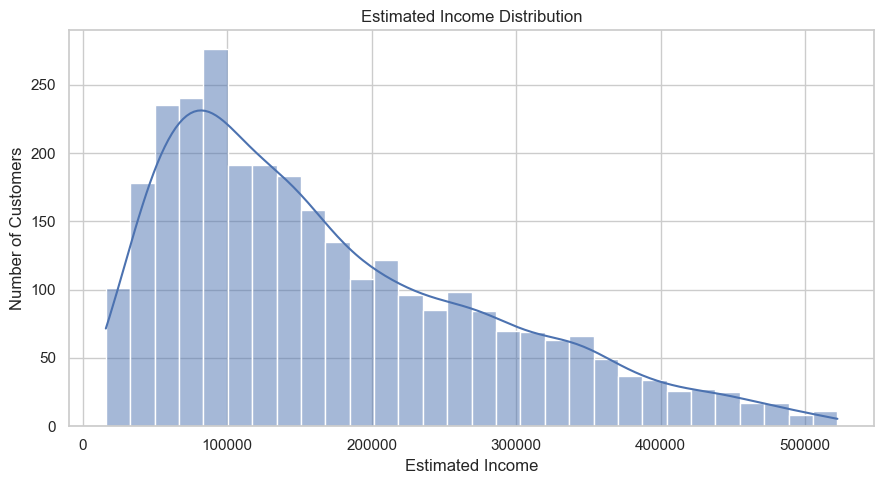

In [18]:
#Income Distribution

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="Estimated Income",
    bins=30,
    kde=True
)

plt.title("Estimated Income Distribution")
plt.xlabel("Estimated Income")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

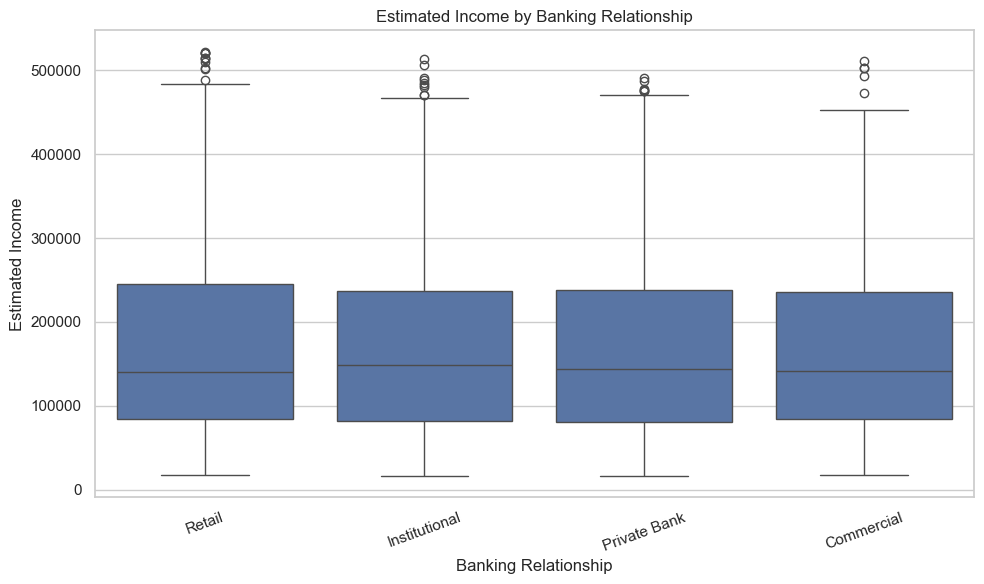

In [19]:
#Income by Banking Relationship
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Banking Relationship",
    y="Estimated Income"
)

plt.title(
    "Estimated Income by Banking Relationship"
)

plt.xlabel("Banking Relationship")
plt.ylabel("Estimated Income")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

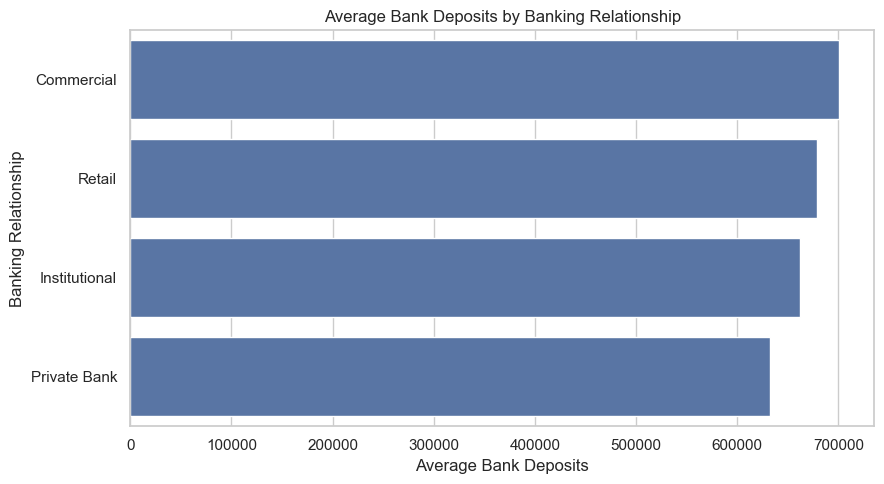

In [20]:
#Bank Deposits by Relationship

deposit_analysis = (
    df.groupby("Banking Relationship")[
        "Bank Deposits"
    ]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=deposit_analysis.values,
    y=deposit_analysis.index
)

plt.title(
    "Average Bank Deposits by Banking Relationship"
)

plt.xlabel("Average Bank Deposits")
plt.ylabel("Banking Relationship")

plt.tight_layout()
plt.show()

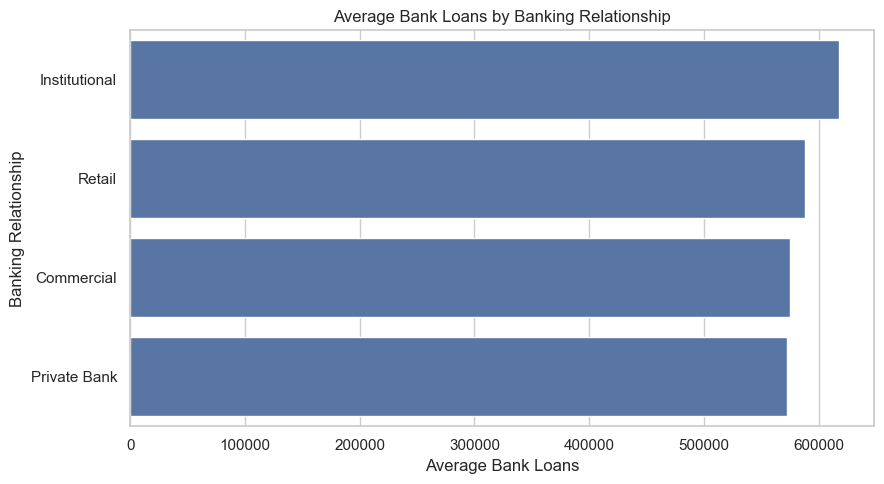

In [21]:
#Loans by Relationship

loan_analysis = (
    df.groupby("Banking Relationship")[
        "Bank Loans"
    ]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=loan_analysis.values,
    y=loan_analysis.index
)

plt.title(
    "Average Bank Loans by Banking Relationship"
)

plt.xlabel("Average Bank Loans")
plt.ylabel("Banking Relationship")

plt.tight_layout()
plt.show()

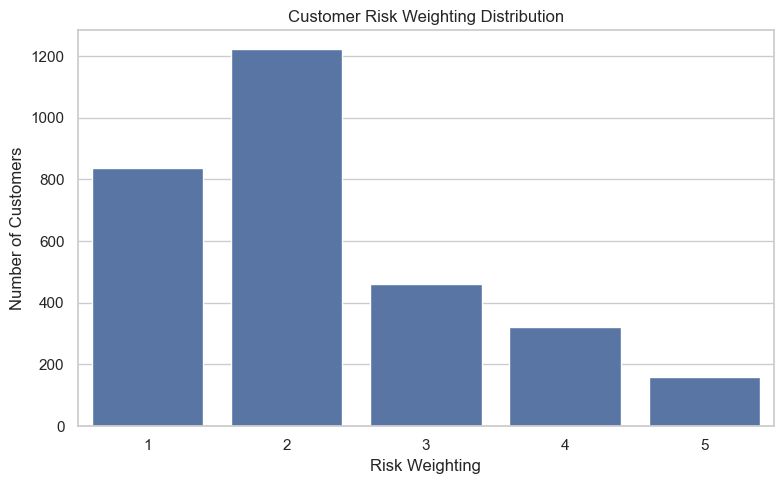

In [22]:
#Risk Weighting Distribution

risk_count = (
    df["Risk Weighting"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=risk_count.index.astype(str),
    y=risk_count.values
)

plt.title("Customer Risk Weighting Distribution")
plt.xlabel("Risk Weighting")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [ ]:
#Risk vs Income

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="Risk Weighting",
    y="Estimated Income"
)

plt.title(
    "Estimated Income Across Risk Weighting"
)

plt.xlabel("Risk Weighting")
plt.ylabel("Estimated Income")

plt.tight_layout()
plt.show()

In [ ]:
#Risk vs Loans

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="Risk Weighting",
    y="Bank Loans"
)

plt.title(
    "Bank Loans Across Risk Weighting"
)

plt.xlabel("Risk Weighting")
plt.ylabel("Bank Loans")

plt.tight_layout()
plt.show()

In [ ]:
#Credit Card Analysis
credit_card_analysis = (
    df.groupby("Amount of Credit Cards")[
        "Credit Card Balance"
    ]
    .mean()
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=credit_card_analysis.index,
    y=credit_card_analysis.values
)

plt.title(
    "Average Credit Card Balance by Number of Cards"
)

plt.xlabel("Number of Credit Cards")
plt.ylabel("Average Credit Card Balance")

plt.tight_layout()
plt.show()

In [ ]:
#Financial Correlation
financial_columns = [
    "Age",
    "Estimated Income",
    "Superannuation Savings",
    "Amount of Credit Cards",
    "Credit Card Balance",
    "Bank Loans",
    "Bank Deposits",
    "Checking Accounts",
    "Saving Accounts",
    "Foreign Currency Account",
    "Business Lending",
    "Properties Owned",
    "Risk Weighting"
]

correlation = df[
    financial_columns
].corr()

correlation

In [ ]:
#Correlation Heatmap

plt.figure(figsize=(13, 9))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title(
    "Financial Variables Correlation Matrix"
)

plt.tight_layout()
plt.show()

In [ ]:
#Top Customers by Income

top_income_customers = (
    df[
        [
            "Client ID",
            "Name",
            "Estimated Income",
            "Bank Deposits",
            "Bank Loans",
            "Risk Weighting"
        ]
    ]
    .sort_values(
        by="Estimated Income",
        ascending=False
    )
    .head(10)
)

top_income_customers

In [ ]:
#Top Customers by Deposits

top_deposit_customers = (
    df[
        [
            "Client ID",
            "Name",
            "Bank Deposits",
            "Estimated Income",
            "Banking Relationship"
        ]
    ]
    .sort_values(
        by="Bank Deposits",
        ascending=False
    )
    .head(10)
)

top_deposit_customers

In [ ]:
#Customer Segment Summary
segment_summary = (
    df.groupby(
        "Loyalty Classification"
    )
    .agg(
        Customers=("Client ID", "count"),
        Average_Income=("Estimated Income", "mean"),
        Average_Deposits=("Bank Deposits", "mean"),
        Average_Loans=("Bank Loans", "mean"),
        Average_Risk=("Risk Weighting", "mean")
    )
    .sort_values(
        "Average_Income",
        ascending=False
    )
)

segment_summary

In [ ]:
#Banking Relationship Summary

relationship_summary = (
    df.groupby(
        "Banking Relationship"
    )
    .agg(
        Customers=("Client ID", "count"),
        Average_Income=("Estimated Income", "mean"),
        Average_Deposits=("Bank Deposits", "mean"),
        Average_Loans=("Bank Loans", "mean"),
        Average_Credit_Balance=("Credit Card Balance", "mean"),
        Average_Risk=("Risk Weighting", "mean")
    )
    .sort_values(
        "Average_Income",
        ascending=False
    )
)

relationship_summary

In [ ]:

# KEY BUSINESS INSIGHTS


largest_relationship = (
    df["Banking Relationship"]
    .value_counts()
    .idxmax()
)

highest_income_relationship = (
    relationship_summary[
        "Average_Income"
    ].idxmax()
)

highest_deposit_relationship = (
    relationship_summary[
        "Average_Deposits"
    ].idxmax()
)

highest_loan_relationship = (
    relationship_summary[
        "Average_Loans"
    ].idxmax()
)

largest_loyalty_segment = (
    df["Loyalty Classification"]
    .value_counts()
    .idxmax()
)

highest_risk_group = (
    df.groupby("Risk Weighting")[
        "Bank Loans"
    ]
    .mean()
    .idxmax()
)


print("=" * 65)
print("              KEY BUSINESS INSIGHTS")
print("=" * 65)

print(
    "\nLargest Banking Relationship:",
    largest_relationship
)

print(
    "Highest Average Income Relationship:",
    highest_income_relationship
)

print(
    "Highest Average Deposit Relationship:",
    highest_deposit_relationship
)

print(
    "Highest Average Loan Relationship:",
    highest_loan_relationship
)

print(
    "Largest Loyalty Segment:",
    largest_loyalty_segment
)

print(
    "Risk Group with Highest Average Loans:",
    highest_risk_group
)

In [ ]:

# FINAL PROJECT REPORT


print("\n")
print("=" * 70)
print("        REAL-WORLD BANKING DATA PROJECT")
print("=" * 70)

print("\nDATASET SUMMARY")
print("-" * 70)

print("Total Customers:", df["Client ID"].nunique())
print("Total Features:", df.shape[1])

print(
    "Average Customer Age:",
    round(df["Age"].mean(), 2)
)

print(
    "Average Estimated Income:",
    round(df["Estimated Income"].mean(), 2)
)

print(
    "Average Bank Deposits:",
    round(df["Bank Deposits"].mean(), 2)
)

print(
    "Average Bank Loans:",
    round(df["Bank Loans"].mean(), 2)
)

print("\nDATA QUALITY")
print("-" * 70)

print(
    "Missing Values:",
    df.isnull().sum().sum()
)

print(
    "Duplicate Records:",
    df.duplicated().sum()
)

print("\nKEY FINDINGS")
print("-" * 70)

print(
    "Largest Banking Relationship:",
    largest_relationship
)

print(
    "Highest Income Relationship:",
    highest_income_relationship
)

print(
    "Highest Deposit Relationship:",
    highest_deposit_relationship
)

print(
    "Highest Loan Relationship:",
    highest_loan_relationship
)

print(
    "Largest Loyalty Segment:",
    largest_loyalty_segment
)

print(
    "Highest Loan Risk Group:",
    highest_risk_group
)

print("\nPROJECT COMPLETED SUCCESSFULLY!")
print("=" * 70)